In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1.A/B-тестирование

В качестве входных данных имеем 4 csv-файла:

groups.csv – файл с информацией о принадлежности пользователя к контрольной или экспериментальной группе (А – контроль, B – целевая группа);  
groups_add.csv – дополнительный файл с пользователями, который вам прислали спустя 2 дня после передачи данных;  
active_studs.csv – файл с информацией о пользователях, которые зашли на платформу в дни проведения эксперимента;   
checks.csv – файл с информацией об оплатах пользователей в дни проведения эксперимента. 

##### Предобработка данных

In [4]:
#Считываем данные
df_active_users = pd.read_csv('active_studs.csv')
df_checks = pd.read_csv('checks.csv', sep = ';')
df_groups_add = pd.read_csv('group_add.csv')
df_groups = pd.read_csv('groups.csv', sep = ';')


In [5]:
df_active_users.head(3)

,student_id
0,581585
1,5723133
2,3276743


In [6]:
df_checks.head(3)

,student_id,rev
0,1627,990.0
1,3185,690.0
2,25973,690.0


In [7]:
df_groups_add.head(3)

,id,grp
0,5694584,B
1,5694830,B
2,5695057,B


In [8]:
df_groups.head(3)

,id,grp
0,1489,B
1,1627,A
2,1768,B


Проверим наличие NaN и дубликатов:

In [9]:
df_active_users.duplicated().sum()

0

In [10]:
df_checks.duplicated().sum()

0

In [11]:
df_groups_add.duplicated().sum()

0

In [12]:
df_groups.duplicated().sum()

0

$\implies$ дубликаты отсутствуют

In [13]:
df_active_users.isna().sum().sum()

0

In [14]:
df_checks.isna().sum().sum()

0

In [15]:
df_groups_add.isna().sum().sum()

0

In [16]:
df_groups.isna().sum().sum()

0

$\implies$ NaN-ы отсутствуют

Проверим rev на наличие выбросов:

<Axes: xlabel='rev'>

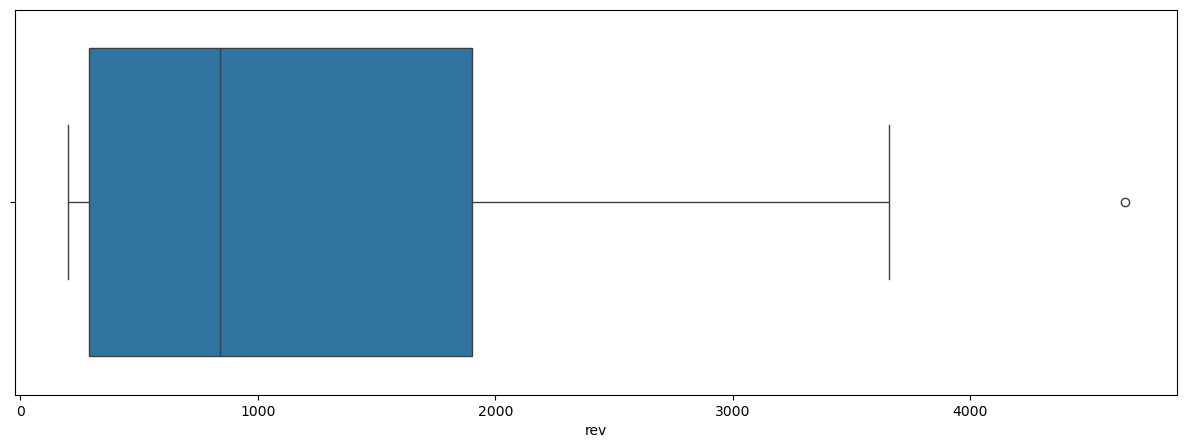

In [17]:
plt.figure(figsize = (15,5))
sns.boxplot(data = df_checks, x = 'rev')

In [18]:
#Boxplot показывает наличие одного аномально большого значения, проверим данные
q_1 = df_checks['rev'].quantile(0.25)
q_3 = df_checks['rev'].quantile(0.75)
iqr = q_3 - q_1
df_checks[df_checks['rev'] >= (q_3 + 1.5*iqr)]

,student_id,rev
231,1711305,4650.0


Наличие одного крупного платежа скорее всего не является выбросом

In [19]:
#Объединяем df_groups и df_groups_add
groups = pd.concat([df_groups, df_groups_add])

In [20]:
#Оставляем активных пользователей
df_users = groups.merge(df_active_users, how = 'inner', left_on = 'id', right_on = 'student_id')

In [21]:
#Объединяем с данными об опалатах
df = df_users.merge(df_checks, how = 'left', left_on = 'id', right_on = 'student_id')

In [22]:
df = df.drop(['student_id_x', 'student_id_y'], axis = 1)

In [23]:
#Заполним nan-ы в стобце rev нулями
df['rev'] = df['rev'].fillna(0)

In [24]:
#Добавляем признак оплаты
df['paid'] = (df['rev'] > 0).astype('int')

In [25]:
df.head(3)

,id,grp,rev,paid
0,1627,A,990.0,1
1,2085,B,0.0,0
2,2215,B,0.0,0


##### Выбор метрик

1. Конверсия в оплату (CR)
2. Average revenue per user (ARPU)  = Общая выручка / Число пользоваетелей  

Обоснование: Конверсия в оплату хорошо отражает, насколько новая механика проще, понятнее и быстрее для пользователя, или наоборот. Уменьшение конверсии свидетельствовало бы о том, что пользователи чаще бросают процесс оплаты, что говорило бы о неудачной новой механике. ARPU же отражает бизнес-показатели и помогает исключить дешёвые транзакции при увеличении CR

Проверим статистические различия в конверсии с помощью Z-теста для пропорций (т.к. данный статистический тест исопльзуется для проверки гипотез о доле бинарного признака). Группы независимы, размер выборки большой $\implies$ можем применить Z-тест.

$H_0$ - конверсии одинаковы;  
$H_1$ - конверсии различаются.

In [26]:
#Считаем конверсию для группы A
df.query("grp == 'A'")['paid'].sum()/df[df['grp'] == 'A'].shape[0] * 100

5.071521456436931

In [27]:
#Считаем конверсию для группы B
df.query("grp == 'B'")['paid'].sum()/df[df['grp'] == 'B'].shape[0] * 100

4.615610759958842

In [28]:
from statsmodels.stats.proportion import proportions_ztest

In [29]:
#Считаем количество платящих пользователей в контрольной и тестовой группе
A_paid = df.query("grp == 'A'")['paid'].sum()
B_paid = df.query("grp == 'B'")['paid'].sum()
z_test, p_value = proportions_ztest(count = [A_paid, B_paid], nobs = [df[df['grp'] == 'A'].shape[0], df[df['grp'] == 'B'].shape[0]])

In [30]:
p_value

0.445470284371589

Статистически значимые различия в конверсии отсутствуют

Проверим различие в метрике ARPU.  
$H_0$ - различия отсутствуют;  
$H_1$ - есть различие.  

<Axes: xlabel='rev', ylabel='Count'>

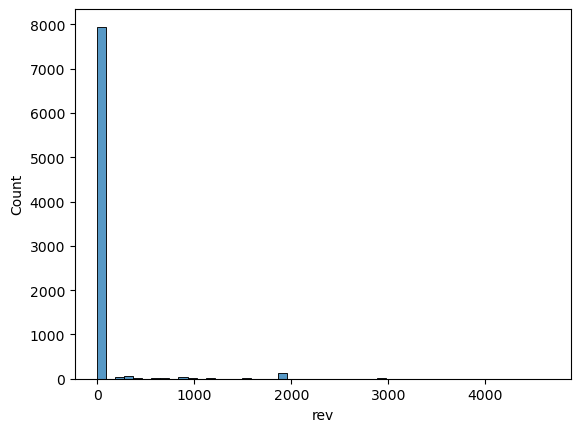

In [31]:
sns.histplot(df['rev'], bins = 50)

В распределении много нулей, есть несколько крупных платежей

In [32]:
#Проверим нормальность с помощью теста Д'агостино.
from scipy.stats import normaltest
stat, p_value = normaltest(df['rev'])
stat, p_value

(9966.537441497881, 0.0)

In [33]:
group_A = df[df['grp'] == 'A']['rev'].values
group_B = df[df['grp'] == 'B']['rev'].values

<Axes: ylabel='Count'>

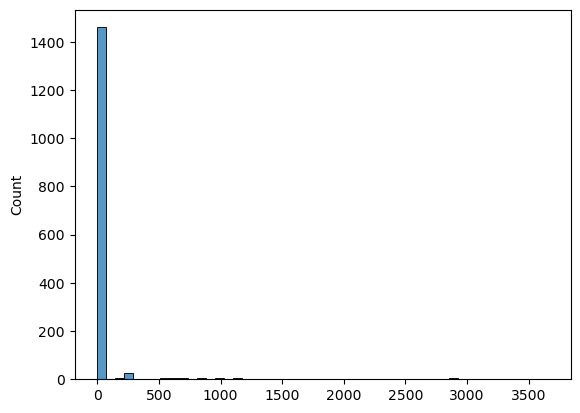

In [34]:
sns.histplot(group_A, bins = 50)

<Axes: ylabel='Count'>

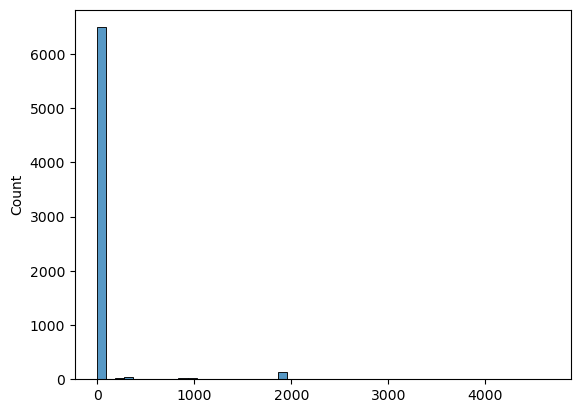

In [35]:
sns.histplot(group_B, bins = 50)

Поскольку распределение не является нормальными и сильно разреженное, стандартные статистические тесты неприменимы. Применим bootstrap

In [36]:
n = 10000
diffs = []

for i in range(n):
    sample_A = np.random.choice(group_A, size=len(group_A),replace=True)
    sample_B = np.random.choice(group_B, size=len(group_B),replace=True)
    diffs.append(sample_B.mean() - sample_A.mean())

In [37]:
#Считаем доверительный интервал
low = np.percentile(diffs, 2.5)
high = np.percentile(diffs, 97.5)
print(low, high)

-6.343018121300417 26.465508964563643


Доверительный интервал содержит ноль $\rightarrow$ статистически значимые различия отсутствуют.

##### Вывод

Статистические тесты показали отсутствие статистически значимых различий в метриках CR и ARPU на контрольной и тестовой группах. Запускать новую механику не рекомендуется.